In [3]:
import pandas as pd
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
file_path = "../clean_data/clean_dataset.xlsx"

all_sheet = pd.read_excel(file_path, sheet_name=None)

df_sales_orders = all_sheet["sales_orders_clean"]
df_purchase_orders = all_sheet["purchase_orders_clean"]
df_product_master = all_sheet["product_master_clean"]
df_supplier_master = all_sheet["supplier_master_clean"]
df_warehouse_master = all_sheet["warehouse_master_clean"]

Analysis Goals

In [5]:
"""
This comapany wants to get information about revenue that they get, revenue based on:
1. Revenue per month 
2. Revenue history in a whole year
3. Revenue based on every product
4. Revenue based on customer region
5. 
"""

'\nThis comapany wants to get information about revenue that they get, revenue based on:\n1. Revenue per month \n2. Revenue history in a whole year\n3. Revenue based on every product\n4. Revenue based on customer region\n5. \n'

Preparing Revenue Data

In [6]:
# Gross_Profit: (quantity_sold * unit_price) as Total_Revenue - (quantity_sold * unit_cost) as Total_COGS
df_sales_orders["Total_Revenue"] = df_sales_orders["Quantity_Sold"] * df_sales_orders["Unit_Price"]
df_sales_orders["Total_COGS"] = df_sales_orders["Quantity_Sold"] * df_sales_orders["Unit_Cost"]
df_sales_orders["Gross_Profit"] = df_sales_orders["Total_Revenue"] - df_sales_orders["Total_COGS"]

In [7]:
# Get months by using accessor
df_sales_orders["Month"] = df_sales_orders["Order_Date"].dt.month_name()
df_sales_orders["Year"] = df_sales_orders["Order_Date"].dt.strftime("%Y")
# We only have 2025 data

In [8]:
# Total Gross Profit per month
gross_profit_per_month = df_sales_orders.groupby(
    [df_sales_orders["Order_Date"].dt.month.rename("Month_Num"), "Month"]
).agg(
    Total_Gross_Profit=("Gross_Profit", "sum")
).reset_index().sort_values("Month_Num").drop(columns=["Month_Num"]).set_index("Month")

gross_profit_per_month

,Total_Gross_Profit
Month,
January,472997.55
February,476541.03
March,443192.86
April,528237.43
May,382266.48
June,354188.06
July,506357.67
August,724724.83
September,422025.96


C:\Users\Alexander Wasistho\AppData\Local\Temp\ipykernel_11684\2577153010.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


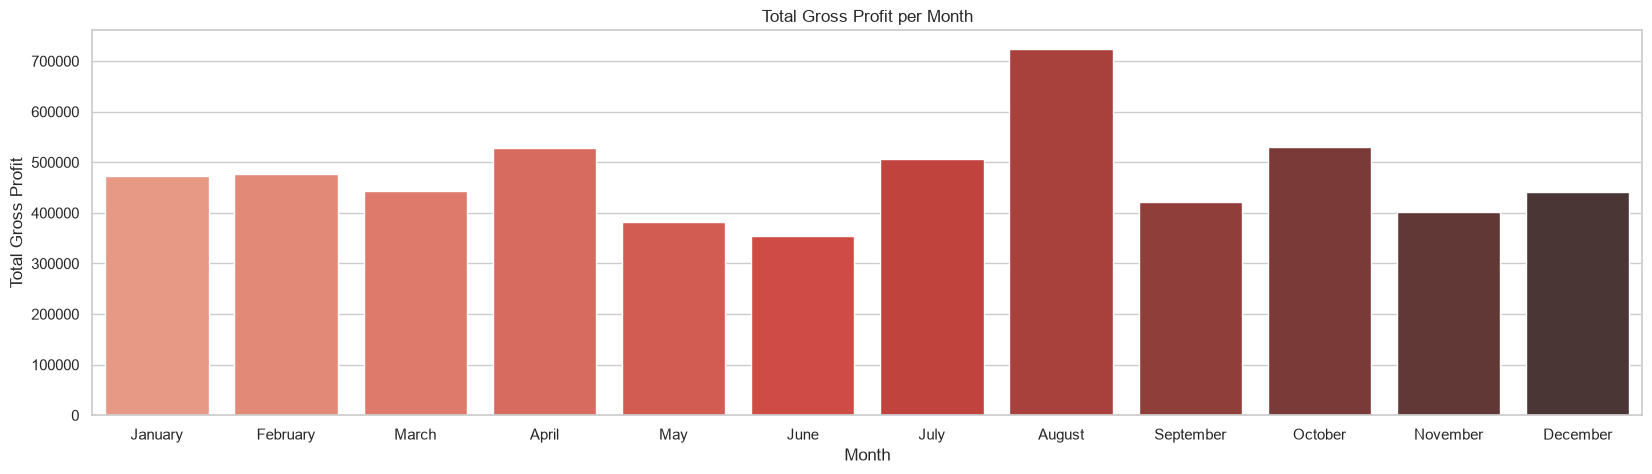

In [9]:
# Revenue per Month Visualiza

plt.figure(figsize=(20, 5))
sns.set_theme(style="whitegrid")

sns.barplot(
    data = gross_profit_per_month,
    x = "Month",
    y = "Total_Gross_Profit",
    palette = "Reds_d"
)

plt.title("Total Gross Profit per Month")
plt.xlabel("Month")
plt.ylabel("Total Gross Profit")

plt.show()

C:\Users\Alexander Wasistho\AppData\Local\Temp\ipykernel_11684\3753045801.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


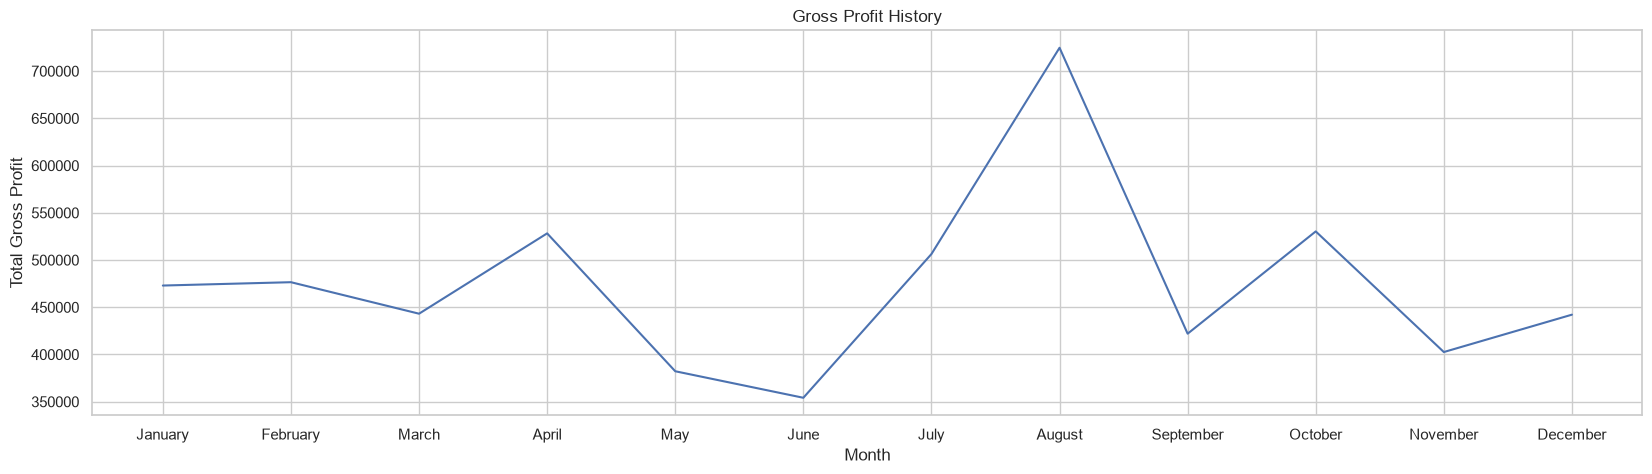

In [10]:
# Revenue History
plt.figure(figsize=(20, 5))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data = gross_profit_per_month,
    x = "Month",
    y = "Total_Gross_Profit",
    palette = "Reds_d"
)

plt.title("Gross Profit History")
plt.xlabel("Month")
plt.ylabel("Total Gross Profit")
plt.show()

In [11]:
# 3. Revenue based on every product
# Analyzing top 5 product with highest revenue 

# Get product and total revenue

product_revenue = df_sales_orders.groupby("Product_Name").agg(
    Total_Gross_Profit = ("Gross_Profit", "sum")
).sort_values(by="Total_Gross_Profit", ascending=False).head()

product_revenue

,Total_Gross_Profit
Product_Name,
Cordless Drill 18V,339266.20
Polyethylene Pellets,322004.16
Gear Set Helical,315071.94
Motor Bracket Assembly,301340.34
Bluetooth Speaker Mini,292849.76


C:\Users\Alexander Wasistho\AppData\Local\Temp\ipykernel_11684\955499958.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


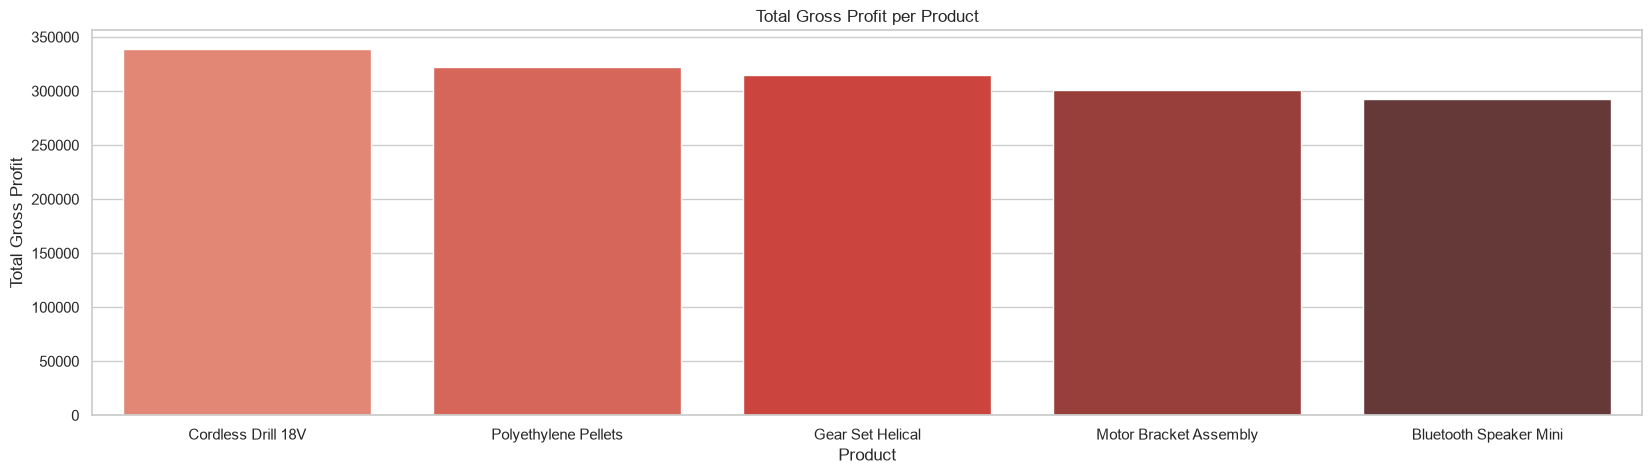

In [12]:
# Visualization
plt.figure(figsize=(20, 5))
sns.set_theme(style="whitegrid")

sns.barplot(
    data = product_revenue,
    x = "Product_Name",
    y = "Total_Gross_Profit",
    palette = "Reds_d"
)

plt.title("Total Gross Profit per Product")
plt.xlabel("Product")
plt.ylabel("Total Gross Profit")

plt.show()

In [13]:
# 4. Revenue based on customer region
# Which region contributes the most to revenue

region_data = df_sales_orders.groupby("Customer_Region").agg(
    Total_Gross_Profit = ("Gross_Profit", "sum")
).sort_values(by="Total_Gross_Profit", ascending=False)

C:\Users\Alexander Wasistho\AppData\Local\Temp\ipykernel_11684\4224872625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


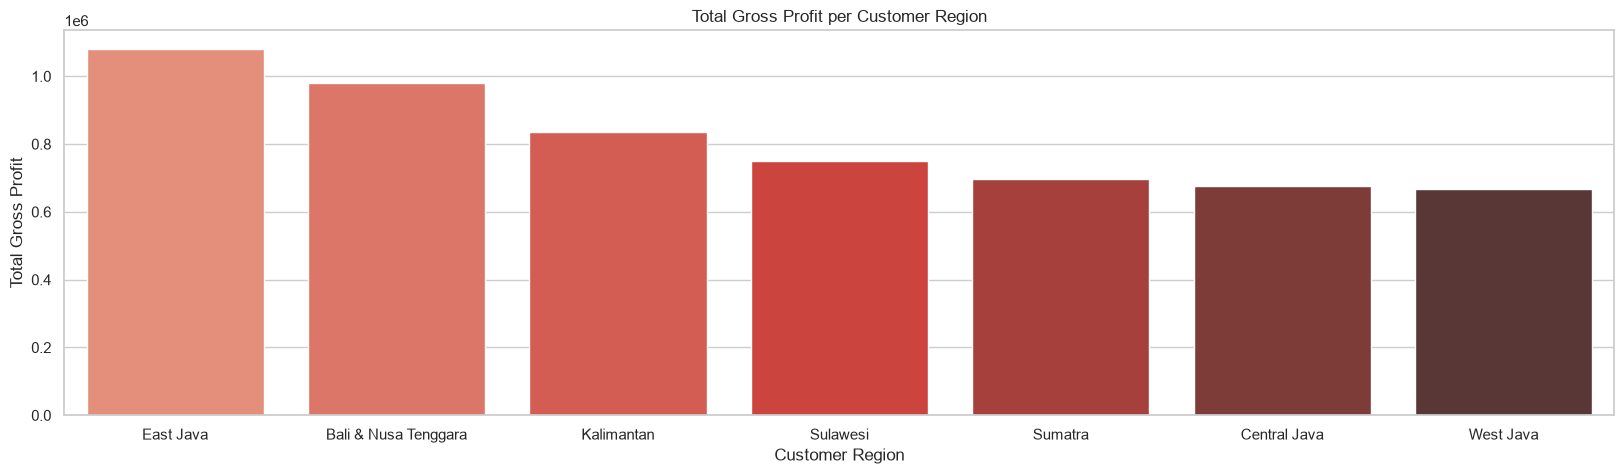

In [ ]:
plt.figure(figsize=(30, 10))
sns.set_theme(style="whitegrid")

sns.barplot(
    data = region_data,
    x = "Customer_Region",
    y = "Total_Gross_Profit",
    palette = "Reds_d"
)

plt.title("Total Gross Profit per Customer Region")
plt.xlabel("Customer Region")
plt.ylabel("Total Gross Profit")

plt.show()